<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/07_2_%ED%85%8D%EC%8A%A4%ED%8A%B8_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%8B%A4%EB%A3%A8%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## 01 예제 애플리케이션: 영화 리뷰 감성 분석
- 데이터셋: 1-10점 중 7점 이상은 "양성", 4점 이하는 "음성"인 이진 분류 데이터 (중간은 포함하지 않음)

In [3]:
# 데이터 다운
!wget -nc http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz -P data
!tar xzf data/aclImdb_v1.tar.gz --skip-old-files -C data

File ‘data/aclImdb_v1.tar.gz’ already there; not retrieving.



In [4]:
!find ./data -type d

./data
./data/aclImdb
./data/aclImdb/test
./data/aclImdb/test/neg
./data/aclImdb/test/pos
./data/aclImdb/train
./data/aclImdb/train/neg
./data/aclImdb/train/unsup
./data/aclImdb/train/pos


In [5]:
# 사용하지 않는 폴더 삭제
!rm -r data/aclImdb/train/unsup
!find ./data -type d

./data
./data/aclImdb
./data/aclImdb/test
./data/aclImdb/test/neg
./data/aclImdb/test/pos
./data/aclImdb/train
./data/aclImdb/train/neg
./data/aclImdb/train/pos


In [6]:
from sklearn.datasets import load_files

reviews_train = load_files("data/aclImdb/train/")
text_train, y_train = reviews_train.data, reviews_train.target
print(f"text_train의 타입: {type(text_train)}")
print(f"text_train의 길이: {len(text_train)}")
print(f"text_train[6]:\n{text_train[6]}")

text_train의 타입: <class 'list'>
text_train의 길이: 25000
text_train[6]:
b"This movie has a special way of telling the story, at first i found it rather odd as it jumped through time and I had no idea whats happening.<br /><br />Anyway the story line was although simple, but still very real and touching. You met someone the first time, you fell in love completely, but broke up at last and promoted a deadly agony. Who hasn't go through this? but we will never forget this kind of pain in our life. <br /><br />I would say i am rather touched as two actor has shown great performance in showing the love between the characters. I just wish that the story could be a happy ending."


In [7]:
# HTML 태그 삭제
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

In [8]:
# 같은 비율의 양성과 음성 레이블
print(f"클래스별 샘플 수 (훈련 데이터): {np.bincount(y_train)}")

클래스별 샘플 수 (훈련 데이터): [12500 12500]


In [9]:
reviews_test = load_files("data/aclImdb/test/")
text_test, y_test = reviews_test.data, reviews_test.target
print(f"테스트 데이터의 문서 수: {len(text_test)}")
print(f"클래스별 샘플 수 (테스트 데이터): {np.bincount(y_test)}")
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

테스트 데이터의 문서 수: 25000
클래스별 샘플 수 (테스트 데이터): [12500 12500]


## 02 텍스트 데이터를 BOW로 표현하기
- BOW(bag of words)
  - 가장 간단하지만 효과적이면서 널리 쓰이는 방법
  - 장, 문단, 문장, 서식 같은 입력 텍스트의 구조 대부분을 잃고, 각 단어가 이 말뭉치에 있는 텍스트에 얼마나 많이 나타나는지만 헤아림
  - 구조와 상관없이 단어의 출현 횟수만 셈
- BOW의 단계
  1. 토큰화(tokenization): 각 문서를 문서에 담긴 단어(토큰)로 나눔. 예를 들어 공백이나 구두점을 기준으로 분리
  2. 어휘 사전 구축: 모든 문서에 나타난 모든 단어의 어휘를 모으고 번호를 매김 (알파벳 순서)
  3. 인코딩: 어휘 사전의 단어가 문서마다 몇 번이나 나타나는지를 헤아림
- 출력은 각 문서에 나타난 단어의 횟수가 담긴 하나의 벡터

### 2.1 샘플 데이터에 BOW 적용하기

In [10]:
# 데이터 준비
bards_words = ["The fool doth think he is wise",
               "but the wise man knows himself to be a fool"]

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

In [12]:
# CountVectorizer.fit(): 토큰으로 나누고 어휘 사전을 구축
print(f"어휘 사전의 크기: {len(vect.vocabulary_)}")
print(f"어휘 사전의 내용:\n{vect.vocabulary_}")

어휘 사전의 크기: 13
어휘 사전의 내용:
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [13]:
# CountVectorizer.transform(): BOW 표현을 만듦
bag_of_words = vect.transform(bards_words)
print(f"BOW: {repr(bag_of_words)}")

BOW: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


- BOW 표현은 0이 아닌 값만 저장하는 희소 행렬로 저장 (특성 배열의 대부분의 원소가 0이라서 희소 행렬을 사용)
- 각각의 행은 하나의 데이터 포인트, 각 특성은 어휘 사전에 있는 각 단어에 대응

In [14]:
print(f"BOW의 밀집 표현:\n{bag_of_words.toarray()}")

BOW의 밀집 표현:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


- 각 단어의 출현 횟수는 0아니면 1
- 👉 두 문자열 모두 같은 단어를 두 개 이상 가지고 있지 않음
- 첫 번째 문자열 `The fool doth think he is wise`는 첫 번째 행으로 나타나며, 어휘 사전의 첫 번째 단어 `be`가 0번 나옴, 세 번째 단어 `doth`는 1번 나옴

### 2.2 영화 리뷰에 대한 BOW

In [15]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train:\n{repr(X_train)}")

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


In [16]:
feature_names = vect.get_feature_names_out()
print(f"특성 개수:{len(feature_names)}")
print(f"처음 20개 특성:\n{feature_names[:20]}")
print(f"20010에서 20030까지 특성:\n{feature_names[20010:20030]}")
print(f"매 2000번째 특성:\n{feature_names[::2000]}")

특성 개수:74849
처음 20개 특성:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
20010에서 20030까지 특성:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
매 2000번째 특성:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


- 희소 행렬의 고차원 데이터셋에서는 `LogisticRegression`같은 선형 모델의 성능이 가장 뛰어남

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=1000), X_train, y_train,
                         n_jobs=-1)
print(f"교차 검증 평균 점수: {round(np.mean(scores), 2)}")

교차 검증 평균 점수: 0.88


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")
print(f"최적의 매개변수: {grid.best_params_}")

최상의 교차 검증 점수: 0.89
최적의 매개변수: {'C': 0.1}


In [19]:
X_test = vect.transform(text_test)
print(f"테스트 점수: {round(grid.score(X_test, y_test), 2)}")

테스트 점수: 0.88


#### 2.2.1 단어 추출 방법 개선
- 숫자 같은 의미 없는 특성이 생성되는 것을 줄이는 방법: 적어도 두 개의 문서 (또는 다섯 개의 문서 등)에 나타난 토큰만을 사용

In [20]:
# min_df 매개변수로 토큰이 나타날 최소 문서 개수 지정
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print(f"min_df로 제한한 X_train: {repr(X_train)}")

min_df로 제한한 X_train: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


In [21]:
feature_names = vect.get_feature_names_out()

print(f"처음 50개 특성:\n{feature_names[:50]}")
print(f"20010부터 20030까지 특성:\n{feature_names[20010:20030]}")
print(f"매 700번째 특성:\n{feature_names[::700]}")

처음 50개 특성:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
20010부터 20030까지 특성:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
매 700번째 특성:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 'tvs' 'vampyre' 'western

In [22]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.89


- 모델 성능은 높아지지 않았지만 특성의 개수가 줄어서 처리 속도가 빨라지고, 불필요한 특성이 없어져 모델을 이해하기 쉬워짐

## 03 불용어
- 의미 없는 단어를 제거하는 또 다른 방법: 너무 빈번하여 유용하지 않은 단어를 제거
- 1️⃣ 언어별 불용어 목록을 사용
- 2️⃣ 너무 자주 나타나는 단어를 제거
- `sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`: 영어의 불용어

In [24]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(f"불용어 개수: {len(ENGLISH_STOP_WORDS)}")
print(f"매 10번째 불용어:\n{list(ENGLISH_STOP_WORDS)[::10]}")

불용어 개수: 318
매 10번째 불용어:
['put', 'sincere', 'everywhere', 'across', 'call', 'how', 'very', 'empty', 'by', 'however', 'was', 'towards', 'sixty', 'becomes', 'up', 'may', 'four', 'first', 'than', 'due', 'him', 'their', 'too', 'those', 'in', 'go', 'few', 'eg', 'further', 'made', 'together', 'cannot']


In [25]:
#stop_words="english": 내장된 불용어 사용

vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print(f"불용어가 제거된 X_train:\n{repr(X_train)}")

불용어가 제거된 X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


In [26]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.88


- 👉 모델 해석이 나아지지 않았으므로 불용어 목록을 사용하는 것이 도움이 되지 않음
- 고정된 불용어 목록은 모델이 데이터셋만 보고 불용어를 골라내기 어려운 작은 데이터셋에서 동무이 됨

## 04 tf-idf로 데이터 스케일 변경하기
- 얼마나 의미 있는 특성인지를 계산해서 스케일을 조정하는 방식
- tf-idf
  - 말뭉치의 다른 문서보다 특성 문서에서 자주 나타나는 단어에 높은 가중치를 주는 방법
  - 한 단어가 특정 문서에 자주 나타나고 다른 여러 문서에서는 그렇지 않다면, 그 문서의 내용을 아주 잘 설명하는 단어라고 봄

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, n_jobs=-1)
grid.fit(text_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.89


- 👉 tf-idf가 성능에 큰 영향을 주지 못함
- tf-idf는 어떤 단어가 가장 중요한지도 알려줌
- 문서를 구별하는 단어를 찾는 방법이지만 완전히 비지도 학습 ➡️ '긍정적인 리뷰'와 '부정적인 리뷰' 레이블과 꼭 관계있지 않음!

In [31]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]

# 훈련 데이터셋을 변환
X_train = vectorizer.transform(text_train)

# 특성 별로 가장 큰 값을 찾음
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()

# 특성 이름 구하기
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"가장 낮은 tfidf를 가진 특성:\n{feature_names[sorted_by_tfidf[:20]]}")
print(f"가장 높은 tfidf를 가진 특성:\n{feature_names[sorted_by_tfidf[-20:]]}")

가장 낮은 tfidf를 가진 특성:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
가장 높은 tfidf를 가진 특성:
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


- tf-idf가 낮은 특성은 전체 문서에 걸쳐 매우 많이 나타나거나, 조금씩만 사용되거나, 매우 긴 문서에서만 사용됨
- tf-idf가 높은 특성은 특정한 쇼나 드라마에 대한 리뷰 등 특정 리뷰에서 매우 자주 나타남

In [32]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print(f"가장 낮은 idf를 가진 특성:\n {feature_names[sorted_by_idf[:100]]}")

가장 낮은 idf를 가진 특성:
 ['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


## 05 모델 계수 조사


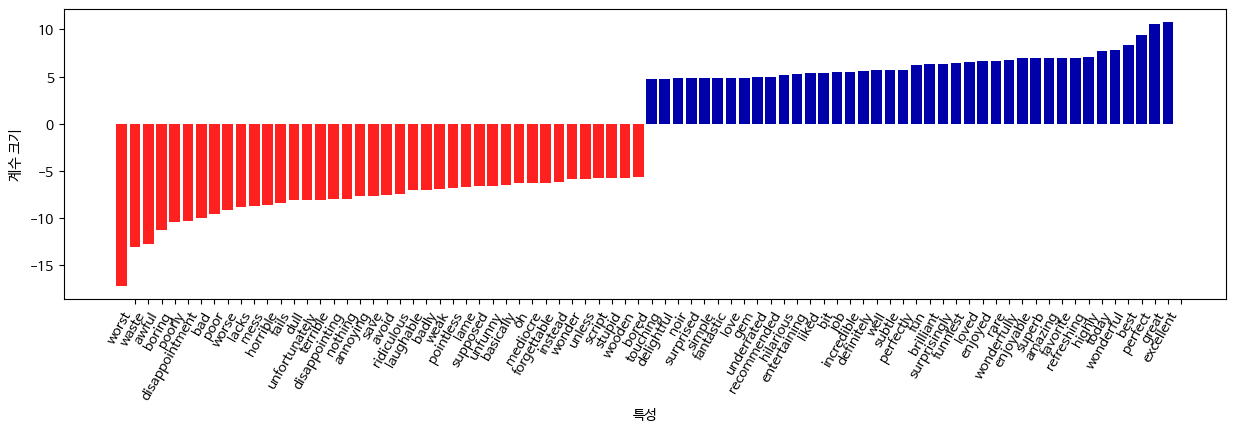

In [33]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_[0],
    feature_names, n_top_features=40
)

- 왼쪽의 음수 계수는 모델에서 부정적인 리뷰를 의미하는 단어에 속하고, 오른쪽 양수 계수는 긍정적인 리뷰의 단어에 해당
- 대부분의 단어는 매우 직관적